In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


df = pd.read_csv("student_placement_career_success.csv")
df.head()

,student_id,age,gender,state,city,city_tier,college_tier,branch,degree,cgpa,...,certifications_count,aptitude_score,coding_score,dsa_score,communication_score,attendance_percentage,preferred_role,placement_status,placement_probability,salary_lpa
0,STU00001,21,Female,Karnataka,Mangaluru,Tier 2,Tier 2,Data Science,B.E.,8.65,...,1,69,80,54,55,89.03,Data Scientist,Not Placed,0.4623,0.00
1,STU00002,24,Male,Karnataka,Mysuru,Tier 3,Tier 3,CSE,B.Tech,8.28,...,1,77,100,74,61,75.28,Software Developer,Placed,0.8008,5.98
2,STU00003,24,Female,Karnataka,Bengaluru,Tier 2,Tier 3,Data Science,B.Tech,7.91,...,1,78,77,54,71,89.75,Data Scientist,Placed,0.8148,4.65
3,STU00004,21,Male,Andhra Pradesh,Tirupati,Tier 1,Tier 1,ECE,B.Tech,8.57,...,4,59,56,55,73,78.95,Embedded Engineer,Not Placed,0.6769,0.00
4,STU00005,21,Male,Gujarat,Ahmedabad,Tier 2,Tier 3,ECE,B.Tech,7.71,...,2,51,45,42,53,79.29,Embedded Engineer,Placed,0.5568,2.50


In [4]:
df.shape

(5000, 23)

In [5]:
print(df.columns.tolist())

['student_id', 'age', 'gender', 'state', 'city', 'city_tier', 'college_tier', 'branch', 'degree', 'cgpa', 'backlog_history', 'internship_experience', 'projects_count', 'certifications_count', 'aptitude_score', 'coding_score', 'dsa_score', 'communication_score', 'attendance_percentage', 'preferred_role', 'placement_status', 'placement_probability', 'salary_lpa']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5000 non-null   object 
 1   age                    5000 non-null   int64  
 2   gender                 5000 non-null   object 
 3   state                  5000 non-null   object 
 4   city                   5000 non-null   object 
 5   city_tier              5000 non-null   object 
 6   college_tier           5000 non-null   object 
 7   branch                 5000 non-null   object 
 8   degree                 5000 non-null   object 
 9   cgpa                   5000 non-null   float64
 10  backlog_history        5000 non-null   int64  
 11  internship_experience  5000 non-null   object 
 12  projects_count         5000 non-null   int64  
 13  certifications_count   5000 non-null   int64  
 14  aptitude_score         5000 non-null   int64  
 15  codi

In [7]:
missing = df.isnull().sum()

print(missing)

student_id               0
age                      0
gender                   0
state                    0
city                     0
city_tier                0
college_tier             0
branch                   0
degree                   0
cgpa                     0
backlog_history          0
internship_experience    0
projects_count           0
certifications_count     0
aptitude_score           0
coding_score             0
dsa_score                0
communication_score      0
attendance_percentage    0
preferred_role           0
placement_status         0
placement_probability    0
salary_lpa               0
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

student_id               0.0
age                      0.0
gender                   0.0
state                    0.0
city                     0.0
city_tier                0.0
college_tier             0.0
branch                   0.0
degree                   0.0
cgpa                     0.0
backlog_history          0.0
internship_experience    0.0
projects_count           0.0
certifications_count     0.0
aptitude_score           0.0
coding_score             0.0
dsa_score                0.0
communication_score      0.0
attendance_percentage    0.0
preferred_role           0.0
placement_status         0.0
placement_probability    0.0
salary_lpa               0.0
dtype: float64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print("Duplicate student IDs:", df["student_id"].duplicated().sum())

Duplicate student IDs: 0


In [11]:
print(df["placement_status"].value_counts())

placement_status
Placed        3083
Not Placed    1917
Name: count, dtype: int64


In [12]:
df["placement_status"].value_counts(normalize=True) * 100

placement_status
Placed        61.66
Not Placed    38.34
Name: proportion, dtype: float64

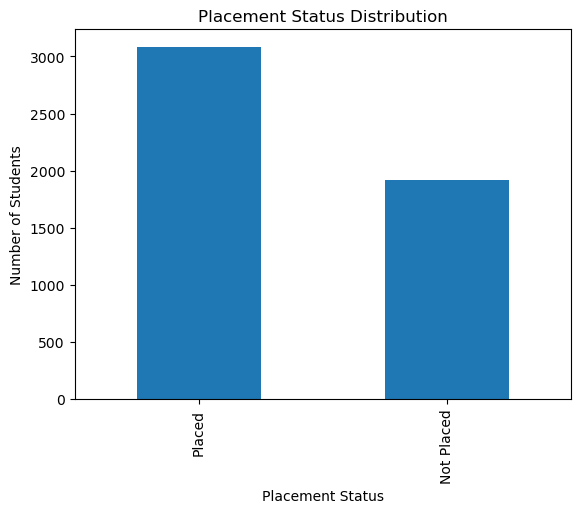

In [13]:
df["placement_status"].value_counts().plot(
    kind="bar"
)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

In [14]:
df.describe()

,age,cgpa,backlog_history,projects_count,certifications_count,aptitude_score,coding_score,dsa_score,communication_score,attendance_percentage,placement_probability,salary_lpa
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,22.01220,7.812118,0.40980,2.015400,2.016200,69.11300,71.587000,65.22360,66.515600,81.931606,0.624833,2.880404
std,1.40842,0.907051,0.75125,1.395834,1.422372,12.73043,15.970455,15.86571,13.753166,8.012114,0.173631,2.478038
min,20.00000,5.000000,0.00000,0.000000,0.000000,25.00000,20.000000,15.00000,20.000000,55.000000,0.061900,0.000000
25%,21.00000,7.200000,0.00000,1.000000,1.000000,61.00000,61.000000,54.00000,57.000000,76.600000,0.507850,0.000000
50%,22.00000,7.800000,0.00000,2.000000,2.000000,69.00000,72.000000,66.00000,66.000000,82.040000,0.644850,3.490000
75%,23.00000,8.420000,1.00000,3.000000,3.000000,78.00000,83.000000,76.00000,76.000000,87.430000,0.759250,4.970000
max,24.00000,10.000000,3.00000,6.000000,8.000000,100.00000,100.000000,100.00000,100.000000,100.000000,0.957800,9.020000


In [15]:
numeric_features = [
    "age",
    "cgpa",
    "backlog_history",
    "projects_count",
    "certifications_count",
    "aptitude_score",
    "coding_score",
    "dsa_score",
    "communication_score",
    "attendance_percentage"
]

In [16]:
categorical_features = [
    "gender",
    "state",
    "city",
    "city_tier",
    "college_tier",
    "branch",
    "degree",
    "internship_experience",
    "preferred_role"
]

In [17]:
for col in categorical_features:
    print("\n", col)
    print(df[col].unique())


 gender
['Female' 'Male' 'Other']

 state
['Karnataka' 'Andhra Pradesh' 'Gujarat' 'Tamil Nadu' 'West Bengal'
 'Uttar Pradesh' 'Maharashtra' 'Telangana' 'Kerala' 'Delhi']

 city
['Mangaluru' 'Mysuru' 'Bengaluru' 'Tirupati' 'Ahmedabad' 'Coimbatore'
 'Vijayawada' 'Durgapur' 'Noida' 'Mumbai' 'Hyderabad' 'Kochi' 'Delhi'
 'Visakhapatnam' 'Kanpur' 'New Delhi' 'Karimnagar' 'Madurai'
 'Thiruvananthapuram' 'Nagpur' 'Surat' 'Warangal' 'Vadodara' 'Chennai'
 'Kozhikode' 'Lucknow' 'Kolkata' 'Pune']

 city_tier
['Tier 2' 'Tier 3' 'Tier 1']

 college_tier
['Tier 2' 'Tier 3' 'Tier 1']

 branch
['Data Science' 'CSE' 'ECE' 'Civil' 'EEE' 'Mechanical' 'ISE' 'AI & ML']

 degree
['B.E.' 'B.Tech']

 internship_experience
['No' 'Yes']

 preferred_role
['Data Scientist' 'Software Developer' 'Embedded Engineer'
 'Civil Engineer' 'Electrical Engineer' 'Design Engineer'
 'Full Stack Developer' 'Machine Learning Engineer']


In [18]:
for col in numeric_features:
    print(
        f"{col}: "
        f"min={df[col].min()}, "
        f"max={df[col].max()}"
    )

age: min=20, max=24
cgpa: min=5.0, max=10.0
backlog_history: min=0, max=3
projects_count: min=0, max=6
certifications_count: min=0, max=8
aptitude_score: min=25, max=100
coding_score: min=20, max=100
dsa_score: min=15, max=100
communication_score: min=20, max=100
attendance_percentage: min=55.0, max=100.0


In [22]:
X = df.drop(
    columns=[
        "student_id",
        "placement_status",
        "placement_probability",
        "salary_lpa"
    ]
)

y = df["placement_status"]

In [20]:
X = df.drop(
    columns=[
        "student_id",
        "placement_status",
        "placement_probability",
        "salary_lpa"
    ]
)

y = df["placement_status"]

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 19)
y shape: (5000,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [26]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [28]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [29]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'cgpa',
                                                   'backlog_history',
                                                   'projects_count',
                                                   'certifications_count',
                                                   'aptitude_score',
                                                   'coding_score', 'dsa_score',
                                                   'communication_score',
                                                   'attendance_percentage']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'state', 'city',
                                                   'city_tier', 'college_tier',
                                                   'branch', 'degree',
                                                   'internship_experience',
                                                   'preferred_role'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [30]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [31]:
print("Logistic Regression")
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_lr,
        pos_label="Placed"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_lr,
        pos_label="Placed"
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        y_pred_lr,
        pos_label="Placed"
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        (y_test == "Placed").astype(int),
        y_prob_lr
    )
)

Logistic Regression
Accuracy: 0.656
Precision: 0.6842105263157895
Recall: 0.8217179902755267
F1: 0.7466863033873343
ROC-AUC: 0.6885121725184185


In [32]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=150,
            max_depth=8,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [33]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'cgpa',
                                                   'backlog_history',
                                                   'projects_count',
                                                   'certifications_count',
                                                   'aptitude_score',
                                                   'coding_score', 'dsa_score',
                                                   'communication_score',
                                                   'attendance_percentage']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'state', 'city',
                                                   'city_tier', 'college_tier',
                                                   'branch', 'degree',
                                                   'internship_experience',
                                                   'preferred_role'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        n_estimators=150, random_state=42))])

In [34]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [35]:
gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.1,
            max_depth=4,
            random_state=42
        )
    )
])

In [36]:
gradient_boosting_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'cgpa',
                                                   'backlog_history',
                                                   'projects_count',
                                                   'certifications_count',
                                                   'aptitude_score',
                                                   'coding_score', 'dsa_score',
                                                   'communication_score',
                                                   'attendance_percentage']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'state', 'city',
                                                   'city_tier', 'college_tier',
                                                   'branch', 'degree',
                                                   'internship_experience',
                                                   'preferred_role'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=150,
                                            random_state=42))])

In [37]:
y_pred_gb = gradient_boosting_model.predict(X_test)

y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [38]:
def evaluate_model(name, y_true, y_pred, y_prob):
    
    accuracy = accuracy_score(
        y_true,
        y_pred
    )
    
    precision = precision_score(
        y_true,
        y_pred,
        pos_label="Placed"
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        pos_label="Placed"
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        pos_label="Placed"
    )
    
    roc_auc = roc_auc_score(
        (y_true == "Placed").astype(int),
        y_prob
    )
    
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

In [39]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb,
        y_prob_gb
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.656,0.684211,0.821718,0.746686,0.688512
1,Random Forest,0.632,0.702439,0.700162,0.701299,0.670853
2,Gradient Boosting,0.634,0.673103,0.790924,0.727273,0.644608


In [40]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
cv_scores = cross_val_score(
    gradient_boosting_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("5-Fold Accuracy Scores:")
print(cv_scores)

print(
    "Mean Accuracy:",
    cv_scores.mean()
)

print(
    "Standard Deviation:",
    cv_scores.std()
)

5-Fold Accuracy Scores:
[0.655 0.66  0.639 0.643 0.653]
Mean Accuracy: 0.65
Standard Deviation: 0.007797435475847178


In [44]:
# Cell 35: Compare the Three Models

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)
y_pred_gb = gradient_boosting_model.predict(X_test)

# Probabilities
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

# Model comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_lr, pos_label="Placed"),
        f1_score(y_test, y_pred_rf, pos_label="Placed"),
        f1_score(y_test, y_pred_gb, pos_label="Placed")
    ],
    
    "ROC-AUC": [
        roc_auc_score(
            (y_test == "Placed").astype(int),
            y_prob_lr
        ),
        roc_auc_score(
            (y_test == "Placed").astype(int),
            y_prob_rf
        ),
        roc_auc_score(
            (y_test == "Placed").astype(int),
            y_prob_gb
        )
    ]
})

comparison

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.656,0.746686,0.688512
1,Random Forest,0.632,0.701299,0.670853
2,Gradient Boosting,0.634,0.727273,0.644608


In [46]:
# Cell 36: Random Forest Feature Importance

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Access the Random Forest model inside the pipeline
rf_model = random_forest_model.named_steps["classifier"]

# Get feature importance
importances = rf_model.feature_importances_

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
feature_importance.head(20)

,Feature,Importance
1,num__cgpa,0.159023
6,num__coding_score,0.137290
5,num__aptitude_score,0.070759
8,num__communication_score,0.056115
9,num__attendance_percentage,0.052280
2,num__backlog_history,0.052171
7,num__dsa_score,0.050170
3,num__projects_count,0.047537
4,num__certifications_count,0.028828
68,cat__internship_experience_Yes,0.024811


In [47]:
random_forest_model.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['age', 'cgpa', 'backlog_history',
                                   'projects_count', 'certifications_count',
                                   'aptitude_score', 'coding_score', 'dsa_score',
                                   'communication_score',
                                   'attendance_percentage']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('encoder',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
             

In [48]:
random_forest_model.named_steps["classifier"].feature_importances_

array([0.01970599, 0.15902289, 0.0521711 , 0.04753722, 0.02882795,
       0.0707586 , 0.13729046, 0.05016956, 0.05611496, 0.0522803 ,
       0.00585069, 0.00741187, 0.00281072, 0.00330077, 0.00361995,
       0.00455321, 0.00397039, 0.00451481, 0.00471849, 0.00384295,
       0.00435   , 0.0038404 , 0.0031173 , 0.00297139, 0.00309539,
       0.00361777, 0.00249967, 0.00427975, 0.0042898 , 0.00482224,
       0.00292916, 0.00315278, 0.00308781, 0.00365384, 0.00277645,
       0.00331499, 0.00303835, 0.00314155, 0.00342196, 0.0029716 ,
       0.00425788, 0.00286608, 0.00217226, 0.00301075, 0.00332906,
       0.00378466, 0.00314116, 0.00420899, 0.00246416, 0.00286842,
       0.00275331, 0.00647846, 0.0068132 , 0.0079151 , 0.00780026,
       0.0066652 , 0.01142493, 0.00381563, 0.00468824, 0.00341733,
       0.00473939, 0.00591752, 0.00395194, 0.0040652 , 0.00490614,
       0.00522779, 0.00704291, 0.02451887, 0.02481069, 0.00309455,
       0.00391841, 0.00541188, 0.00448981, 0.00443301, 0.00354

In [49]:
# Cell 37: Feature Importance Table

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance["Importance_Percentage"] = (
    feature_importance["Importance"] * 100
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance,Importance_Percentage
1,num__cgpa,0.159023,15.902289
6,num__coding_score,0.137290,13.729046
5,num__aptitude_score,0.070759,7.075860
8,num__communication_score,0.056115,5.611496
9,num__attendance_percentage,0.052280,5.228030
2,num__backlog_history,0.052171,5.217110
7,num__dsa_score,0.050170,5.016956
3,num__projects_count,0.047537,4.753722
4,num__certifications_count,0.028828,2.882795
68,cat__internship_experience_Yes,0.024811,2.481069


In [50]:
# Cell 38: Save Processed Student Dataset

# Create a copy of the original dataset
students_processed = df.copy()

# Save as CSV
students_processed.to_csv(
    "students_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")
print("Rows:", students_processed.shape[0])
print("Columns:", students_processed.shape[1])

Processed dataset saved successfully!
Rows: 5000
Columns: 23
